Classifying digits 0-9 with MNIST dataset and Pytorch

In [50]:
import torch
from torch import nn as net
from torchvision import datasets, transforms
from torchsummary import summary
import matplotlib.pyplot as plt

In [51]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((.5), (.5)),
])

dataset = datasets.MNIST('MNIST_data/', download=True, train=True, transform=transform)
testset = datasets.MNIST('MNIST_data/', download=True, train=False, transform=transform)
trainloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

<class 'torch.Tensor'>
torch.Size([64, 1, 28, 28])
torch.Size([64])


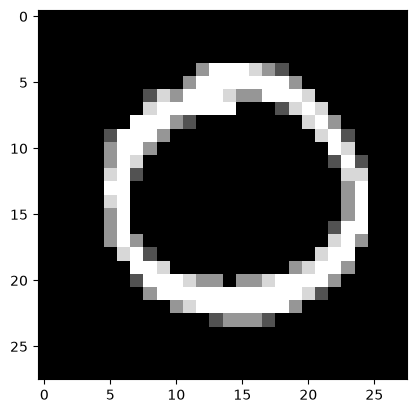

In [52]:
# Printing image info
detailer = iter(trainloader)
images, labels = next(detailer) # each next is a batch
print(type(images))
print(images.shape)
print(labels.shape)

plt.imshow(images[63].numpy().squeeze(), cmap='Greys_r')

In [53]:
# Hyperparameters
filter1 = 16
kernel1 = (2, 2)
stride1 = (1, 1)
filter2 = 32
kernel2 = (2, 2)
stride2 = (1, 1)
pool = (2, 2)

alpha = .0005
delta = .0001 # Regularization parameter
epoch = 30
input_shape = images.shape[1]
img_shape = images.shape[1:4]
output_shape = 10

In [54]:
# Setting up model
model = net.Sequential(
    net.Conv2d(
        in_channels=input_shape,
        out_channels=filter1,
        kernel_size=kernel1,
        stride=stride1,
        padding='valid',
    ),
    net.BatchNorm2d(num_features=filter1),
    net.ReLU(),
    net.MaxPool2d(kernel_size=pool),

    net.Conv2d(
        in_channels=filter1,
        out_channels=filter2,
        kernel_size=kernel2,
        stride=stride2,
        padding='valid',
    ),
    net.BatchNorm2d(num_features=filter2),
    net.ReLU(),
    net.MaxPool2d(kernel_size=pool),

    net.Flatten(),
    net.LazyLinear(
        out_features=output_shape,
    ),
)

summary(model, input_size=img_shape)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 27, 27]              80
       BatchNorm2d-2           [-1, 16, 27, 27]              32
              ReLU-3           [-1, 16, 27, 27]               0
         MaxPool2d-4           [-1, 16, 13, 13]               0
            Conv2d-5           [-1, 32, 12, 12]           2,080
       BatchNorm2d-6           [-1, 32, 12, 12]              64
              ReLU-7           [-1, 32, 12, 12]               0
         MaxPool2d-8             [-1, 32, 6, 6]               0
           Flatten-9                 [-1, 1152]               0
           Linear-10                   [-1, 10]          11,530
Total params: 13,786
Trainable params: 13,786
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.41
Params size (MB): 0.05
Estimated Tot

In [55]:
# Cost and optimization
criterion = net.CrossEntropyLoss()
optimization = torch.optim.Adam(params=model.parameters(), lr=alpha, weight_decay=delta)

In [56]:
model.train() # train mode

for i in range(epoch):
    total_loss = 0

    for batch_images, batch_labels in trainloader:
        optimization.zero_grad() # prevent gradient accumulation

        logits = model(batch_images)
        loss = criterion(logits, batch_labels)

        loss.backward()
        optimization.step()

        total_loss += loss.item()

    if i % 6 == 0:
        avg_loss = total_loss / len(trainloader)
        print(f"Epoch {i}: loss = {avg_loss:.4f}")

Epoch 0: loss = 0.2069
Epoch 6: loss = 0.0296
Epoch 12: loss = 0.0161
Epoch 18: loss = 0.0098
Epoch 24: loss = 0.0072


In [59]:
# Testing and result
model.eval() # switch to evaluation mode

correct = 0
total = 0

with torch.no_grad(): # no need to update gradient
    for batch_images, batch_labels in testloader:
        logits = model(batch_images)
        pred = torch.argmax(logits, dim=1)
        correct += (pred == batch_labels).sum().item()
        total += batch_labels.size(0)

accuracy = correct / total * 100
print('Accuracy: {:.3f}'.format(accuracy))

Accuracy: 98.610
